### General Feed Forward Network 

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

In [4]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

4


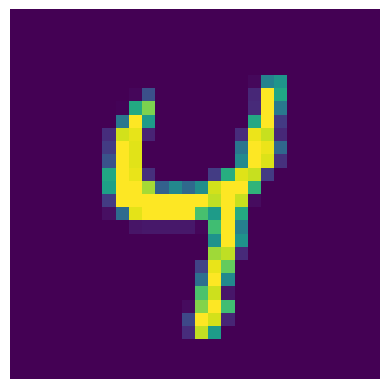

In [5]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [6]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [7]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [8]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### Neural Network Implementation

In [9]:
# Getting the auto-encoder weights in
data = np.load("ae_model_weights.npz")
W1_copy = data["W1"]
b1_copy = data["b1"]
W2_copy = data["W2"]
b2_copy = data["b2"]

In [10]:
len(list(W1_copy))

784

In [34]:
class CustomNeuralNet:

    # Setting new flag to train the input to hidden layer weights or not
    def __init__(self, layers, layer_sizes, momentum=0.9, train_first_layer=True):
        self.layers = layers
        self.layer_sizes = layer_sizes
        self.momentum = momentum
        self.train_first_layer = train_first_layer

        self.W = []
        self.b = []
        self.vW = []
        self.vb = []

        self.W.append(list(W1_copy))
        self.b.append(list(b1_copy[0]))

        self.train_accuracy_over_epochs = []
        self.test_accuracy_over_epochs = []
        self.train_error_over_epochs = []
        self.test_error_over_epochs = []

        # Randomness only for hidden to output layer weights
        for i in range(0, self.layers - 1):
            in_size = layer_sizes[i]
            out_size = layer_sizes[i+1]

            if i != 0:
                W_i = np.random.randn(in_size, out_size) * 0.01
                b_i = np.zeros((1, out_size))

                self.W.append(W_i)
                self.b.append(b_i)

            self.vW.append(np.zeros_like(self.W[i]))
            self.vb.append(np.zeros_like(self.b[i]))

    
    ### Activation Functions
    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_deriv(self, x):
        return 1 - np.tanh(x)**2
    
    ### Forward Pass
    def forward(self, x):
        A = x

        '''
        We store A and Z at every layer so that during backprop we can 
        compute gradients for weights, biases, and previous layers.
        '''
        A_cache = [A]
        Z_cache = []
        
        for i in range(self.layers - 1):
            Z = A @ self.W[i] + self.b[i]       # linear
            A = self.tanh(Z)                   # activation
            Z_cache.append(Z)
            A_cache.append(A)

        return A, Z_cache, A_cache
    
    ### Back propogation
    def backward(self, Y, Z_cache, A_cache):
        m = Y.size

        # Gradients (derivatives)
        dW = [None] * (self.layers - 1)
        db = [None] * (self.layers - 1)

        # Derivative of MSE wrt output activation
        A_final = A_cache[-1]

        if Y.ndim == 1 or Y.shape[1] == 1:
            Y_onehot = np.zeros_like(A_cache[-1])
            Y_onehot[np.arange(len(Y)), Y] = 1
            Y = Y_onehot

        dA = (A_final - Y) * (self.tanh_deriv(Z_cache[-1]))

        offset = 0 if self.train_first_layer else 1

        # Backprop layer by layer
        for i in reversed(range(offset, self.layers - 1)):
            A_prev = A_cache[i]

            dW[i] = (A_prev.T @ dA) / m
            db[i] = np.sum(dA, axis=0, keepdims=True) / m

            if i > offset:
                dA = (dA @ self.W[i].T) * self.tanh_deriv(Z_cache[i-1])

        return dW, db
    
    ### Momentum Update
    def update_params(self, dW, db, lr):
        offset = 0 if self.train_first_layer else 1
        for i in range(offset, self.layers - 1):

            # update momentum buffers
            self.vW[i] = self.momentum * self.vW[i] - lr * dW[i]
            self.vb[i] = self.momentum * self.vb[i] - lr * db[i]

            # update parameters
            self.W[i] += self.vW[i]
            self.b[i] += self.vb[i]

    ### Model Training
    def train(self, X, Y, X_test, Y_test, epochs, lr, batch_size=64):
        n = X.shape[0]   # number of samples

        for epoch in range(epochs):

            perm = np.random.permutation(n)
            X = X[perm]
            Y = Y[perm]

            for i in range(0, n, batch_size):
                X_batch = np.array(X[i:i+batch_size])
                Y_batch = np.array(Y[i:i+batch_size])

                # Forward on this batch only
                A, Z_cache, A_cache = self.forward(X_batch)

                # Backprop on this batch only
                dW, db = self.backward(Y_batch, Z_cache, A_cache)

                # Update
                self.update_params(dW, db, lr)

            if epoch % 10 == 0:
                acc = self.accuracy(X, Y)
                acc2 = self.accuracy(X_test, Y_test)

                self.train_accuracy_over_epochs.append(acc)
                self.test_accuracy_over_epochs.append(acc2)

                self.train_error_over_epochs.append(1 - acc)
                self.test_error_over_epochs.append(1 - acc2)
                print(f"Epoch {epoch} | Accuracy: {acc:.4f}")


    def predict(self, X, show=False):
        A, _, _ = self.forward(X)
        result= np.argmax(A, axis=1)
        if show:
            plt.imshow(X.reshape(28,28).T)
            plt.axis('off')
            plt.show()

        return result

    def visualize_features(self, neuron_indices=None, num_features=20):
        """
        Visualize features learned by hidden neurons.
        Each hidden neuron's weights form a 28x28 image.
        """
        if neuron_indices is None:
            # Randomly select neurons
            num_hidden = self.layer_sizes[1]
            neuron_indices = np.random.choice(num_hidden, num_features, replace=False)
        
        # Get weights from input to hidden layer (first layer)
        W_hidden = self.W[0]  # Shape: (784, num_hidden)
        
        fig, axes = plt.subplots(4, 5, figsize=(10, 8))
        fig.suptitle("Features Learned by Hidden Neurons")
        
        for idx, neuron_idx in enumerate(neuron_indices):
            row = idx // 5
            col = idx % 5
            
            # Get weights for this neuron
            weights = W_hidden[:, neuron_idx]
            
            # Normalize for visualization
            weights_normalized = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
            
            # Reshape to 28x28
            feature_image = weights_normalized.reshape(28, 28).T
            
            axes[row, col].imshow(feature_image, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(f'N{neuron_idx}', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        return neuron_indices

    def accuracy(self, X, Y_onehot):
        predictions = self.predict(X)
        return np.mean(predictions == Y_onehot)

    def plot_accuracy_over_epochs(self):
        epochs = list(range(len(self.train_accuracy_over_epochs)))

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_accuracy_over_epochs, label="Train Accuracy")
        plt.plot(epochs, self.test_accuracy_over_epochs, label="Test Accuracy")

        plt.title("Accuracy Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")

        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

    def plot_error_over_epochs(self):
        epochs = np.arange(len(self.train_error_over_epochs))

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_error_over_epochs, label="Training Error")
        plt.plot(epochs, self.test_error_over_epochs, label="Test Error")

        plt.title("Error Fraction Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Error Fraction")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def confusion_matrix(self, X, Y):
        num_classes = self.layer_sizes[-1]   # should be 10 for MNIST
        cm = np.zeros((num_classes, num_classes), dtype=int)

        predictions = self.predict(X)  # shape (m,)
        
        for true, pred in zip(Y, predictions):
            cm[int(true), int(pred)] += 1

        return cm

    def plot_digit_error_bars(self, X_train, Y_train, X_test, Y_test):
        num_classes = self.layer_sizes[-1]
        
        # Get predictions
        train_preds = self.predict(X_train)
        test_preds = self.predict(X_test)
        
        # Calculate error rates per digit
        train_errors = []
        test_errors = []
        
        for digit in range(num_classes):
            # Training errors for this digit
            train_mask = (Y_train == digit)
            train_correct = (train_preds[train_mask] == digit)
            train_error_rate = 1 - np.mean(train_correct) if np.sum(train_mask) > 0 else 0
            train_errors.append(train_error_rate)
            
            # Test errors for this digit
            test_mask = (Y_test == digit)
            test_correct = (test_preds[test_mask] == digit)
            test_error_rate = 1 - np.mean(test_correct) if np.sum(test_mask) > 0 else 0
            test_errors.append(test_error_rate)
        
        # Create the plot
        digits = np.arange(num_classes)
        x = np.arange(len(digits))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Create bars
        bars1 = ax.bar(x - width/2, train_errors, width, label='Training Error', alpha=0.8, color='steelblue')
        bars2 = ax.bar(x + width/2, test_errors, width, label='Test Error', alpha=0.8, color='coral')
        
        # Customize plot
        ax.set_xlabel('Digit', fontsize=12)
        ax.set_ylabel('Error Rate', fontsize=12)
        ax.set_title('Error Rate by Digit: Training vs Test', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(digits)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\nError Rate Summary:")
        print(f"{'Digit':<8} {'Train Error':<15} {'Test Error':<15}")
        print("-" * 40)
        for digit in range(num_classes):
            print(f"{digit:<8} {train_errors[digit]:<15.4f} {test_errors[digit]:<15.4f}")
        print(f"\n{'Mean':<8} {np.mean(train_errors):<15.4f} {np.mean(test_errors):<15.4f}")


### Applying the nn on the dataset

#### Case 1

In [35]:
nn = CustomNeuralNet(layers=3, layer_sizes=[784, 128, 10], train_first_layer=False)

nn.train(X=X_train, Y=Y_train, X_test=X_test, Y_test=Y_test, epochs=5000, lr=0.01, batch_size=100)

Epoch 0 | Accuracy: 0.1000
Epoch 10 | Accuracy: 0.1000
Epoch 20 | Accuracy: 0.1000
Epoch 30 | Accuracy: 0.1000
Epoch 40 | Accuracy: 0.1000
Epoch 50 | Accuracy: 0.1000
Epoch 60 | Accuracy: 0.1000
Epoch 70 | Accuracy: 0.1040
Epoch 80 | Accuracy: 0.1000
Epoch 90 | Accuracy: 0.1482
Epoch 100 | Accuracy: 0.1000
Epoch 110 | Accuracy: 0.1000
Epoch 120 | Accuracy: 0.1477
Epoch 130 | Accuracy: 0.1000
Epoch 140 | Accuracy: 0.1000
Epoch 150 | Accuracy: 0.1250
Epoch 160 | Accuracy: 0.1000
Epoch 170 | Accuracy: 0.1815
Epoch 180 | Accuracy: 0.1000
Epoch 190 | Accuracy: 0.1000
Epoch 200 | Accuracy: 0.1000
Epoch 210 | Accuracy: 0.1910
Epoch 220 | Accuracy: 0.1148
Epoch 230 | Accuracy: 0.1000
Epoch 240 | Accuracy: 0.1000
Epoch 250 | Accuracy: 0.1153
Epoch 260 | Accuracy: 0.1000
Epoch 270 | Accuracy: 0.1318
Epoch 280 | Accuracy: 0.1263
Epoch 290 | Accuracy: 0.1487
Epoch 300 | Accuracy: 0.1000
Epoch 310 | Accuracy: 0.1000
Epoch 320 | Accuracy: 0.1688
Epoch 330 | Accuracy: 0.1000
Epoch 340 | Accuracy: 0.1

TypeError: list indices must be integers or slices, not tuple

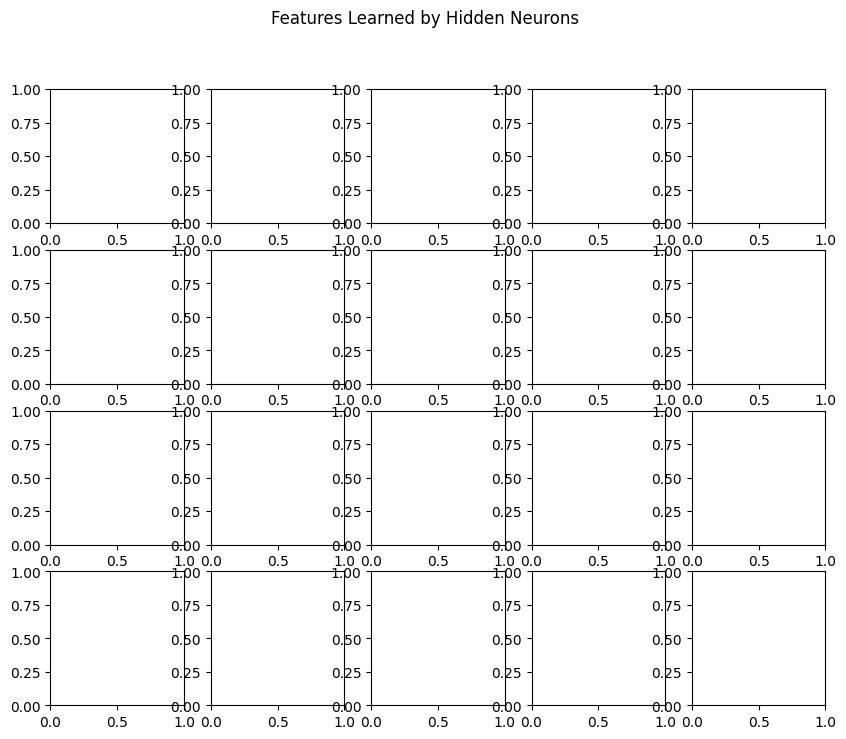

In [36]:
nn.visualize_features(num_features=20)

In [37]:
nn.accuracy(X_test, Y_test)

0.688

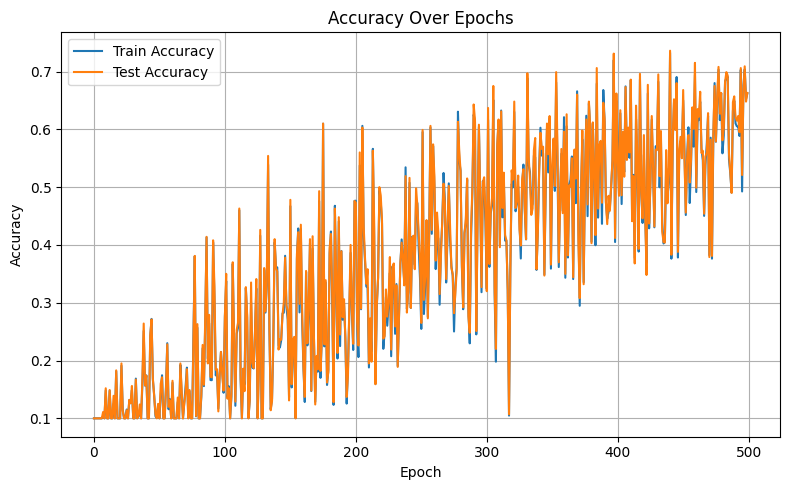

In [38]:
nn.plot_accuracy_over_epochs()

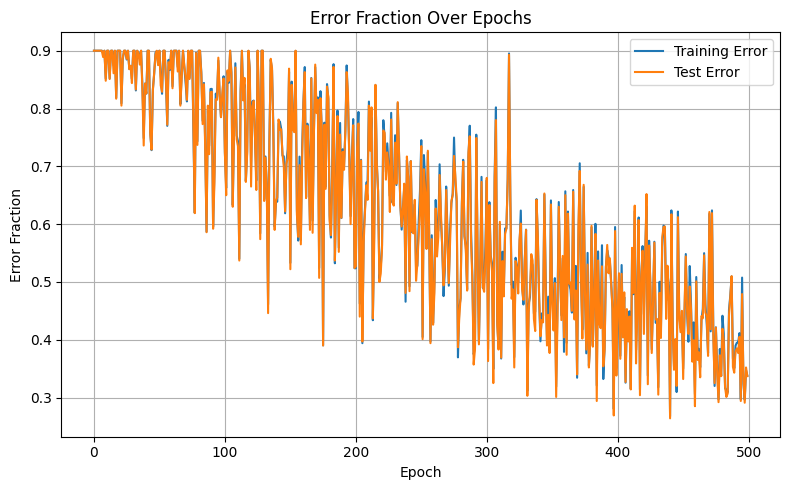

In [39]:
nn.plot_error_over_epochs()

In [40]:
train_cm = nn.confusion_matrix(X_train, Y_train)
test_cm = nn.confusion_matrix(X_test, Y_test)

print("Training Confusion Matrix:\n", train_cm)
print("Test Confusion Matrix:\n", test_cm)

Training Confusion Matrix:
 [[369   0  12   0   0   2   7   0  10   0]
 [  0 364  33   0   0   0   1   0   2   0]
 [  7   9 367   0   2   0   3   6   6   0]
 [  5  51 114 142   3  16   2  14  53   0]
 [  5  15   9   0 347   0   2   6  16   0]
 [ 20  25  45   0  27 182   6  10  85   0]
 [ 15  15  72   0   5   4 276   0  13   0]
 [  7  25  40   0  19   0   0 303   5   1]
 [ 11  36  54   0   7   2   3   7 280   0]
 [  8  18  20   0 244   0   0  66  22  22]]
Test Confusion Matrix:
 [[97  1  0  0  0  0  1  0  1  0]
 [ 0 89 10  0  0  0  0  0  1  0]
 [ 0  4 89  0  1  0  1  4  1  0]
 [ 3  6 26 38  1  4  0  4 18  0]
 [ 0  7  2  0 87  0  2  1  1  0]
 [ 4  4  9  0  5 59  1  0 18  0]
 [ 5  1 12  0  0  2 77  0  3  0]
 [ 0  7  7  0  6  0  0 80  0  0]
 [ 2 11 10  1  3  0  1  2 70  0]
 [ 2  6  4  0 68  0  0 14  4  2]]


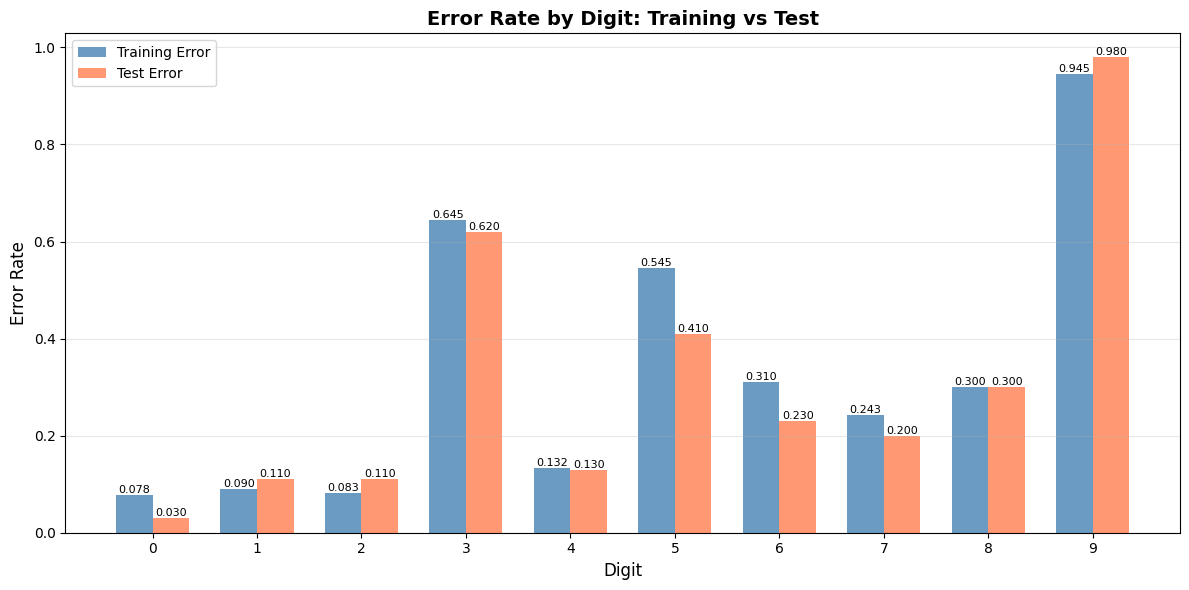


Error Rate Summary:
Digit    Train Error     Test Error     
----------------------------------------
0        0.0775          0.0300         
1        0.0900          0.1100         
2        0.0825          0.1100         
3        0.6450          0.6200         
4        0.1325          0.1300         
5        0.5450          0.4100         
6        0.3100          0.2300         
7        0.2425          0.2000         
8        0.3000          0.3000         
9        0.9450          0.9800         

Mean     0.3370          0.3120         


In [42]:
nn.plot_digit_error_bars(X_train, Y_train, X_test, Y_test)

In [43]:
nn.accuracy(X_train, Y_train)

0.663

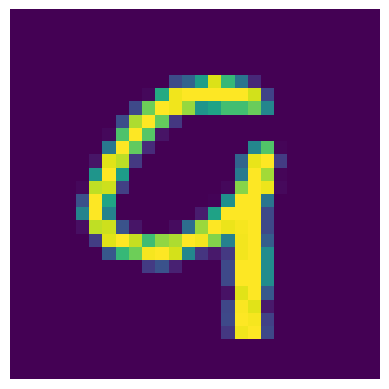

4

In [58]:
index = random.randint(0, 999)
A = nn.predict(X_test[index], show=True)
A[0]

### Case 2

In [59]:
nn = CustomNeuralNet(layers=3, layer_sizes=[784, 128, 10], train_first_layer=True)

nn.train(X=X_train, Y=Y_train, X_test=X_test, Y_test=Y_test, epochs=5000, lr=0.01, batch_size=100)

Epoch 0 | Accuracy: 0.1000
Epoch 10 | Accuracy: 0.1000
Epoch 20 | Accuracy: 0.1000
Epoch 30 | Accuracy: 0.1000
Epoch 40 | Accuracy: 0.1000
Epoch 50 | Accuracy: 0.1000
Epoch 60 | Accuracy: 0.1000
Epoch 70 | Accuracy: 0.1000
Epoch 80 | Accuracy: 0.1000
Epoch 90 | Accuracy: 0.1000
Epoch 100 | Accuracy: 0.1000
Epoch 110 | Accuracy: 0.1000
Epoch 120 | Accuracy: 0.1000
Epoch 130 | Accuracy: 0.1000
Epoch 140 | Accuracy: 0.1000
Epoch 150 | Accuracy: 0.1000
Epoch 160 | Accuracy: 0.1000
Epoch 170 | Accuracy: 0.1000
Epoch 180 | Accuracy: 0.1000
Epoch 190 | Accuracy: 0.1082
Epoch 200 | Accuracy: 0.4360
Epoch 210 | Accuracy: 0.2557
Epoch 220 | Accuracy: 0.2003
Epoch 230 | Accuracy: 0.2172
Epoch 240 | Accuracy: 0.2102
Epoch 250 | Accuracy: 0.1918
Epoch 260 | Accuracy: 0.1945
Epoch 270 | Accuracy: 0.2565
Epoch 280 | Accuracy: 0.3240
Epoch 290 | Accuracy: 0.2330
Epoch 300 | Accuracy: 0.3240
Epoch 310 | Accuracy: 0.4333
Epoch 320 | Accuracy: 0.3892
Epoch 330 | Accuracy: 0.3450
Epoch 340 | Accuracy: 0.4

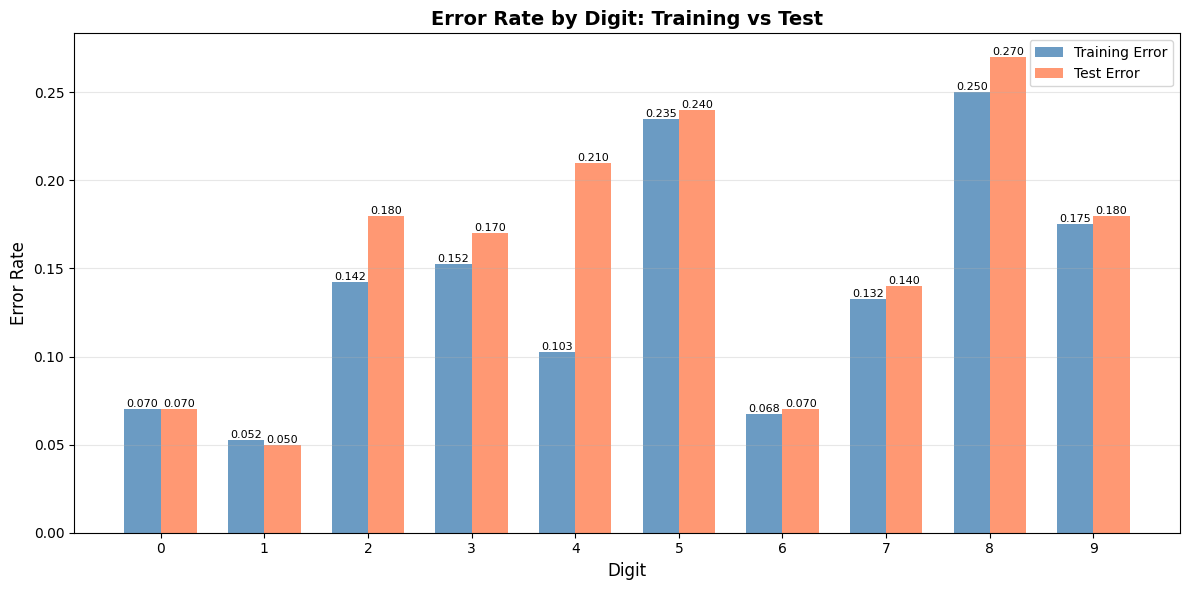


Error Rate Summary:
Digit    Train Error     Test Error     
----------------------------------------
0        0.0700          0.0700         
1        0.0525          0.0500         
2        0.1425          0.1800         
3        0.1525          0.1700         
4        0.1025          0.2100         
5        0.2350          0.2400         
6        0.0675          0.0700         
7        0.1325          0.1400         
8        0.2500          0.2700         
9        0.1750          0.1800         

Mean     0.1380          0.1580         


In [60]:
nn.plot_digit_error_bars(X_train, Y_train, X_test, Y_test)

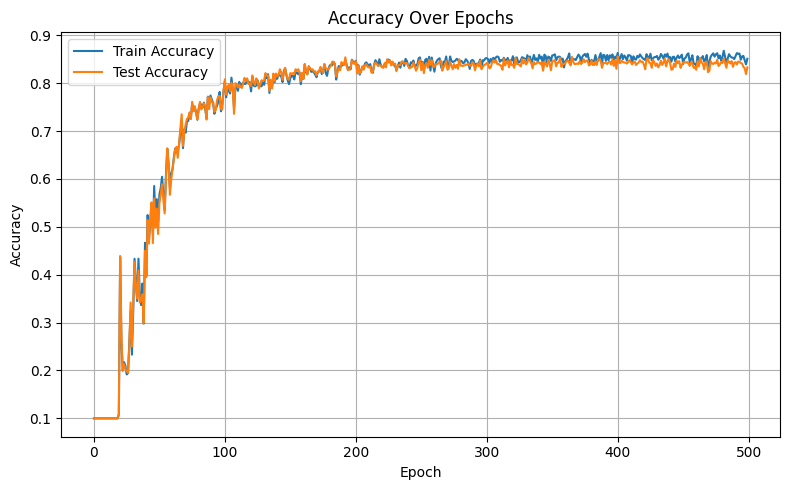

In [61]:
nn.plot_accuracy_over_epochs()

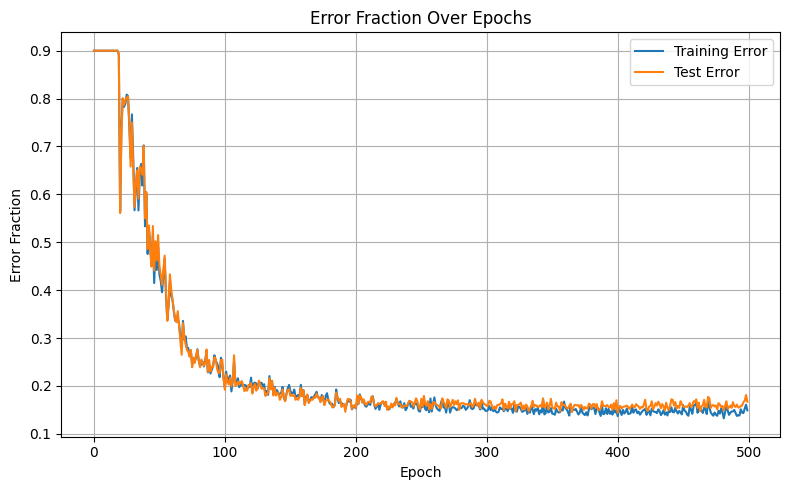

In [62]:
nn.plot_error_over_epochs()

In [64]:
nn.confusion_matrix(X_test, Y_test)

array([[93,  0,  0,  0,  0,  3,  3,  0,  1,  0],
       [ 0, 95,  1,  1,  0,  1,  0,  2,  0,  0],
       [ 2,  3, 82,  3,  1,  0,  1,  6,  2,  0],
       [ 0,  0,  8, 83,  0,  2,  0,  4,  1,  2],
       [ 0,  3,  1,  0, 79,  0,  4,  2,  0, 11],
       [ 2,  2,  2,  3,  2, 76,  3,  3,  6,  1],
       [ 2,  0,  2,  0,  1,  2, 93,  0,  0,  0],
       [ 0,  2,  3,  2,  1,  0,  1, 86,  0,  5],
       [ 1,  3,  1,  4,  3,  3,  4,  5, 73,  3],
       [ 1,  2,  1,  1,  6,  1,  0,  6,  0, 82]])

In [65]:
nn.confusion_matrix(X_train, Y_train)

array([[372,   0,   1,   3,   1,   8,   8,   2,   4,   1],
       [  0, 379,   6,   3,   2,   0,   4,   0,   6,   0],
       [  6,   6, 343,   9,   2,   0,   6,  17,   9,   2],
       [  2,   5,  12, 339,   2,  10,   5,  19,   2,   4],
       [  1,   5,   0,   0, 359,   2,   6,   3,   6,  18],
       [ 10,   7,   1,  27,  12, 306,  13,  11,   9,   4],
       [  9,   5,   1,   0,   4,   7, 373,   1,   0,   0],
       [  2,  14,   7,   2,  10,   1,   2, 347,   1,  14],
       [  6,  21,  11,  23,   9,  11,   8,   7, 300,   4],
       [  5,   6,   1,  10,  12,   0,   1,  30,   5, 330]])

In [136]:
np.savez("model_weights.npz", W1=nn.W[0], b1=nn.b[0], W2=nn.W[1], b2=nn.b[1])

In [137]:
data = np.load("model_weights.npz")
W1_copy = data["W1"]
b1_copy = data["b1"]
W2_copy = data["W2"]
b2_copy = data["b2"]

nn.W[0] == W1_copy

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])